## Install necessary libraries

In [ ]:
#no installation needed

## Importing libraries


Import all libraries that are use in this exercise.

using `pandas` to import the Pandas library into the current Python environment and assign it the alias `pd`. It specifically uses for data manipulation and analysis.



In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
#import dataset
#from google.colab import drive
#drive.mount('/content/drive')
#df = pd.read_csv('/content/drive/MyDrive/ITC508_data/data_supervised.csv')
#check the first 5 instances
#df.head()

# Text Representation Methods
# ----------------------------------------------
## 1. Dictionary Lookup
## 2. One-Hot Encoding
## 3. Bag-of-Words
## 4. TF-IDF


---------------

# Dictionary Lookup

In this section, the variables `sentences` defined as a list containing three sentences examples.

1. `The quick brown fox jumps over the lazy dog`
2. `A journey of a thousand miles begins with a single step`
3.  `To be or not to be that is the question`

The sentence variable will later be used in the extract_words function, where each sentence will be split into individual words and assigned numeric IDs as keys.

**Example output of displaying sentences list**:

  `['The quick brown fox jumps over the lazy dog',
 'A journey of a thousand miles begins with a single step',
 'To be or not to be that is the question']`

In [ ]:
sentences = ["The quick brown fox jumps over the lazy dog",
        "A journey of a thousand miles begins with a single step",
        "To be or not to be that is the question"]
sentences

['The quick brown fox jumps over the lazy dog',
 'A journey of a thousand miles begins with a single step',
 'To be or not to be that is the question']

The `extract_words` function takes a list of sentences, extracts all the unique words from them, and assigns each word a numeric ID. This allows each word to be represented as a number for further text processing tasks.

Syntax:

*   `set()`:  Creates an unordered collection of unique elements, ensuring no duplicate words.
*   `for sentene in sentences`: Loops through each sentence provided in `sentences` variable we defined earlier
*   `words`: Where we stored the split words in the sentence
*   `sentence.split`: Split sentence into a list of words using whitespace as the default delimiter
*   `unique_words.update(words)`: Add each words into this variable and ensure there's no duplicate and so that all the elements in the original set occur only once.
*   `word_dict`: where we stored the value of `unique_words` it represents as word dictionaty
*   `i: word for i, word in enumerate(unique_words)`: iterates through unique_words, returning each words in corresponding numeric index starting with default '0'.

Input of the function is the `sentence` variable with a list of three sentences example.

The function begins by initializing a variable named unique_words as an empty set using set() to store all unique words from the input sentences. A for loop then iterates through each sentence in the sentences list. Within the loop, the sentence.split() method is used to break the sentence into individual words, which are stored in the variable words. These words are then added to the unique_words set using the update() method, ensuring that duplicates are automatically removed.

**Example Output:**

Extracted words with their numeric ID

0: 'the',
1: 'be',
2: 'not',
3: 'of',
4: 'The',
5: 'fox',
6: 'quick',
7: 'journey',
8: 'to',
9: 'To',
10: 'step',
11: 'question',
12: 'lazy',
13: 'dog',
14: 'jumps',
15: 'thousand',
16: 'with',
17: 'single',
18: 'is',
19: 'begins',
20: 'A',
21: 'miles',
22: 'over',
23: 'that',
24: 'brown',
25: 'or',
26: 'a'


In [ ]:
def extract_words(sentences):
    """
    Extracts unique words from a list of sentences and assigns each a numeric ID.
    Args:
        sentences (list of str): A list of sentences.
    Returns:
        dict: A dictionary with numeric IDs as keys and words as values.
    """
    # Split sentences into words and use a set to keep unique words
    unique_words = set()
    for sentence in sentences:
        words = sentence.split()
        unique_words.update(words)

    # Create a dictionary with incrementing numeric IDs as keys
    word_dict = {i: word for i, word in enumerate(unique_words)}

    return word_dict



This code snippet prints a message and then calls a function named extract_words() with sentences as **input**. The function presumably processes the list of sentences to extract unique words and assign a numeric ID (index) to each word.

*   `print("Extracted words with their numeric ID")`: display the extracted words with their corresponding IDs
*   `word_dict`: Calls the function extract_words passing sentences as argument, and stores the returned value in the variable word_dict.
*    `word_dict`: display the content of word_dict


It begin with print `Extracted words with their numeric ID`. The function `extract_words(sentences)` is called with the input sentences (a list of text strings). Inside the function, each sentence is processed by splitting it into words, and each unique word is assigned a numeric ID stored in a dictionary. After all sentences are processed, the dictionary mapping words to their IDs is returned and stored in the variable word_dict. Finally, the code outputs this dictionary, showing the unique words alongside their corresponding numeric identifiers.

Example output:

Extracted words with their numeric ID

{0: 'the',
 1: 'A',
 2: 'brown',
 3: 'to',
 4: 'dog',
 5: 'over',
 6: 'is',
 7: 'not',
 8: 'To',
 9: 'quick',
 10: 'miles',
 11: 'The',
 12: 'journey',
 13: 'jumps',
 14: 'lazy',
 15: 'single',
 16: 'of',
 17: 'or',
 18: 'with',
 19: 'begins',
 20: 'question',
 21: 'thousand',
 22: 'a',
 23: 'step',
 24: 'fox',
 25: 'that',
 26: 'be'}



In [ ]:
print("Extracted words with their numeric ID")
word_dict = extract_words(sentences)
word_dict

Extracted words with their numeric ID


{0: 'to',
 1: 'question',
 2: 'miles',
 3: 'begins',
 4: 'a',
 5: 'step',
 6: 'the',
 7: 'fox',
 8: 'jumps',
 9: 'The',
 10: 'To',
 11: 'of',
 12: 'thousand',
 13: 'brown',
 14: 'quick',
 15: 'be',
 16: 'lazy',
 17: 'that',
 18: 'not',
 19: 'journey',
 20: 'A',
 21: 'single',
 22: 'over',
 23: 'with',
 24: 'or',
 25: 'is',
 26: 'dog'}

In this scenario, the lookup_by_id function takes a dictionary that maps words to numeric IDs as input, along with an ID to search for, then returning the corresponding word if found or a not-found message otherwise. Similarly, the lookup_by_word function searches the dictionary for a given word and returns its numeric ID if found, or a not-found message if the word is absent.



*   `def lookup_by_id(word_dict, numeric_id)`, the loop checks if the given numeric_id equals the current key (id) with if int(numeric_id) == id:. If true, it returns the matching word.

*  `def lookup_by_word(word_dict, word`), the loop checks if the current value (dict_word) equals the given word with if dict_word == word:. If true, it returns the matching ID.


The function `lookup_by_id` accepts two parameters: word_dict, which stores unique words mapped to their numeric IDs, and numeric_id, which is the ID to look up. The function begins with a for id, dict_word in word_dict.items() loop, which iterates over each key-value pair in word_dict using the items() method. Inside the loop, it checks if numeric_id is equal to id. If a match is found, it returns the message **"The numeric id '2' is used to identify the word: the"**. If no match is found after iterating through the dictionary, it returns **"The ID '29' was not found in the dictionary."**

The another function named `lookup_by_word` that contains two parameters: word_dict, to stores unique words and mapped their numeric IDs, and word, which is the word to look up. The function starts with `for id, dict_word in word_dict.items()`, it iterates over each word in word_dict by using the items() method. Within the loop, it checks if dict_word is equal to word, If it's match, it return the message **"The word 'lazy' has the numeric ID: 1"**. Else if isn't match after iterating each word in the dictionary, it returns **"The word 'kevin' was not found in the dictionary."**


**Example output**:

Enter look up key (or 'exit' to quit): 2   
Enter Word (or 'exit' to quit): lazy


Result: The numeric id '2' is used to identify the word: the

Result: The word 'lazy' has the numeric ID: 1

Enter look up key (or 'exit' to quit): exit

Enter Word (or 'exit' to quit): exit

Exiting the program.



Comments and Observations:

* These functions provide a two-way lookup function between words and their assigned numeric IDs, which is useful in NLP tasks when converting between text and numeric representations.

* Possible Improvement: Based on my observations, we can use two dictionaries one to look up words based on their IDs and another to look up IDs based on their words. This way, both lookups are instant, without looping through the entire dictionary and improving efficiency and output speed.



In [ ]:
def lookup_by_id(word_dict, numeric_id):
    # Iterate through the dictionary to find the word
    for id, dict_word in word_dict.items():
        if int(numeric_id) == id:
            return f"The numeric id '{numeric_id}' is used to identify the word: {dict_word}"
    return f"The ID '{numeric_id}' was not found in the dictionary."

def lookup_by_word(word_dict, word):
    # Iterate through the dictionary to find the word
    for id, dict_word in word_dict.items():
        if dict_word == word:
            return f"The word '{word}' has the numeric ID: {id}"

    return f"The word '{word}' was not found in the dictionary."

The program repeatedly prompts the user to enter a lookup ID and a word. If either input is "exit", the program terminates. Otherwise, it uses lookup_by_id and lookup_by_word functions with the user inputs and the word dictionary to display the corresponding word or ID. This loop continues until the user chooses to exit.


*   `user_inputID`: is the variable that stores the user’s input for the numeric ID they want to look up in the dictionary.

*   `user_inputWord`: is the variable that stores the user’s input for the word they want if it has corresponding numeric ID.


*   if `user_inputID.lower() == "exit"` stops the program when the ID input is "exit".
*   if `user_inputWord.lower() == "exit"` stops the program when the word input is "exit".

The inputs comes from the condtion that While it's **True** it executes the two inputs `user_inputID` that takes a look up key and `user_inputWord` gets the Word. Followed by, two conditions:


*   if `user_inputID.lower() == "exit"` it will return exit in the program.
*   if 'user_inputWord.lower() == "exit"` it will also return exit the program.

If it's not exit, it will continue to store the value of each inputs `resultID = lookup_by_id` accepts two values which is `word_dict` (word dictionary) and `user_inputID` (input of the user). Same on the `resultWord = lookup_by_word` variable, retrieve the word dictionary and input of the users.

Example Output:

Enter look up key (or 'exit' to quit): 1
Enter Word (or 'exit' to quit): lazy


Result: The numeric id '1' is used to identify the word: lazy

Result: The word 'lazy' has the numeric ID: 1

Enter look up key (or 'exit' to quit): exit
Enter Word (or 'exit' to quit): exit
Exiting the program.


In [ ]:
 while True:
  user_inputID = input("Enter look up key (or 'exit' to quit): ").strip()
  user_inputWord = input("Enter Word (or 'exit' to quit): ").strip()


  if user_inputID.lower() == 'exit':
    print("Exiting the program.")
    break

  if user_inputWord.lower() == 'exit':
    print("Exiting the program.")
    break

  print("\n");

  resultID = lookup_by_id(word_dict, user_inputID)
  print(f"Result: {resultID}\n")
  resultWord = lookup_by_word(word_dict, user_inputWord)
  print(f"Result: {resultWord}\n")

Enter look up key (or 'exit' to quit): 1
Enter Word (or 'exit' to quit): lazy


Result: The numeric id '1' is used to identify the word: question

Result: The word 'lazy' has the numeric ID: 16

Enter look up key (or 'exit' to quit): exit
Enter Word (or 'exit' to quit): exit
Exiting the program.


# One-Hot Encoding

Import `numpy` as alias np to work through numerical analysis and functions. As well as, its efficient handling of multi-dimensional arrays (ndarrays) and a rich set of mathematical functions to operate on these arrays.

In [ ]:
import numpy as np

**Word-to-Index Mapping**

The variable sentences is defined as a list containing two example sentences: "The cat in the hat" and "The dog in the house". This list serves as the input for the preprocessing step prior to one-hot encoding.


*   `for sentence in sentences`: This outer loop goes through each sentence in the list of sentences, one by one.
*   `for considered_word in sentence.split()`: an inner loop iterates over each considered_word in the sentence, obtained by splitting the sentence into individual words using the split() method.
*   `if word not in token_index`: this condition check if the word is has not already been assigned an Index
*    `token_index[word] = counter + 1`: If the word is new, it adds the word as a key in the token_index dictionary and assigns it a unique integer ID (starting from 1).



The process begins with an outer loop for sentence in sentences, which iterates through each sentence in the list. Inside this loop, an inner loop iterates over each considered_word in the sentence, obtained by splitting the sentence into individual words using the split() method. A conditional check is then performed to determine whether considered_word is already present in the token_index dictionary. If the word is not present, it is considered a new word that requires an ID. The word is then added to token_index using the .update() method, assigning it an ID of counter + 1 so that indexing starts at 1 instead of 0. This approach also ensures that no duplicate words are assigned multiple IDs.

**Example Output**: {'The': 1, 'cat': 2, 'in': 3, 'the': 4, 'hat': 5, 'dog': 6, 'house': 7}


**Comment and Observations**:

* This method is a basic form of tokenization and indexing, often used in Natural Language Processing (NLP) before converting text into vectors.
* `token_index`: dictionary stores words as keys and their assigned numeric IDs as values, which is useful for text processing tasks where words need to be represented in numeric form.
* `if considered_word not in token_index` ondition ensures that each word is assigned an ID only once, avoiding duplicates.
* One limitation is that it treats words with different cases (e.g., "The" and "the") as different tokens, which may not be desired in some applications. Converting all words to lowercase before indexing can fix this.


In [ ]:
sentences = ["The cat in the hat",
"The dog in the house"]
token_index = {}
counter = 0

for sentence in sentences:
  for considered_word in sentence.split():
    if considered_word not in token_index:
      token_index.update({considered_word : counter + 1})
      counter = counter + 1

print(token_index)

{'The': 1, 'cat': 2, 'in': 3, 'the': 4, 'hat': 5, 'dog': 6, 'house': 7}


This code block, creates a initial vectors for one-hot encoded representation. and Shaping the array with comnbination of total number of sentencfes, fixed suize of word slots per sentence, and the vocabulary size which is start at 1.


Start with defining `max_length = 6` to set maximum number of words (token) per sentence that will be stored in the one-hot encoded representation. Followed by, initiliazed `results` contains `np.zeros` functions to creates a new array of specified shapes and types, filled with zeros. The shape of the array is  `np.zeros(shape = (len(sentences), max_length, max(token_index.values()) + 1))` where:


*   `len(sentences)`: represents the total number of sentences
*   `max_length`: specifies the fixed number of word slots per sentence, and
*   `max(token_index.values()) + 1` gives the vocabulary size plus one (the extra 1 is needed because token IDs start at 1, not 0).

At this stage, all values in results are zero, serving as placeholders that will later be replaced with 1.0 at the appropriate positions to represent the actual one-hot encodings. Finally, print("Initial Vectors") displays a label, and results shows the initialized zero-filled matrix.

**Example Output**:

Initial Vectors
array([[[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]]])

**Comments and Observations**:

`np.zeros(shape = (len(sentences), max_length, max(token_index.values()) + 1))`: this is part is essential for shaping the array of one-hot encoded numerical vectors.


In [ ]:
max_length = 6
results  = np.zeros(shape = (len(sentences),
                            max_length,
                            max(token_index.values()) + 1))
print("Initial Vectors")
results

Initial Vectors


array([[[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]]])

This code, converts a list of sentences into a 3D one-hot encoded NumPy array. Each sentence is processed word by word, and the corresponding position in the results array is set to 1 based on the word’s token index, effectively representing each word as a one-hot vector within its sentence context.


Afterwards, iterates over each sentence and each word within the sentence to fill the `results` array with one-hot encoded values. It sets the position corresponding to the word's token ID to 1 in the 3D resuls matrix. where:


*   `for i,sentence in enumerate(sentences)`: Iterates over each sentence and each word and returns both the corresponding index and the sentence string. This loop tells you which sentence you are on.

*   `for j, considered_word in list(enumerate(sentence.split()))`: Loops through each pair from the sentence. `j` is the position of the word in the sentence, then `considered word` get the actual word based on the sentence split. This outer loop tells you which word in that sentence

*   `index = token_index.get(considered_word)`: retrieves the numeric ID of the word from the `token_index` dictionary

*   `print(i,j, sentence, index, considered_word)`: display the values of multiple variables at that moment in the loop.

*    `print(results[i,j])`: print results likely a 3D NumPy array.

*    `results[i, j, index] = 1`: Sets the position in the 3D results array corresponding to (i (sentence index), j (word_ID)) to 1.

**Example Output**:

Document 0: "The cat in the hat"
Sentence 0, Word 0 ('The'): [0. 1. 0. 0. 0. 0. 0. 0.]
Sentence 0, Word 1 ('cat'): [0. 0. 1. 0. 0. 0. 0. 0.]
Sentence 0, Word 2 ('in'): [0. 0. 0. 1. 0. 0. 0. 0.]
Sentence 0, Word 3 ('the'): [0. 0. 0. 0. 1. 0. 0. 0.]
Sentence 0, Word 4 ('hat'): [0. 0. 0. 0. 0. 1. 0. 0.]

Document 1: "The dog in the house"
Sentence 1, Word 0 ('The'): [0. 1. 0. 0. 0. 0. 0. 0.]
Sentence 1, Word 1 ('dog'): [0. 0. 0. 0. 0. 0. 1. 0.]
Sentence 1, Word 2 ('in'): [0. 0. 0. 1. 0. 0. 0. 0.]
Sentence 1, Word 3 ('the'): [0. 0. 0. 0. 1. 0. 0. 0.]
Sentence 1, Word 4 ('house'): [0. 0. 0. 0. 0. 0. 0. 1.]





**Comment and Observations:**

One-hot encoding is a fundamental technique in natural language processing for converting words into a format that machines can process. Below are some key reasons for using this approach, as well as important limitations to keep in mind.


*   Why we apply One-Hot Encoding? It represents the word of sentences as binary vectors. It transform categorical factors into a numerical representation. So that machine learning algorithms can interpret and analyze it.

*  Limitations: as the vocabulary (unique words in the sentence) increase, the vector length grows proportionally, leading to high memory usage and sparsity.

* does not catch the semantic connections between words, machine-learning models that use these vectors as input may perform poorly.

* We can solve this by using other encoding methods, such as Word Embeddings and etc.








In [ ]:
for i, sentence in enumerate(sentences):
    print(f"\nDocument {i}: \"{sentence}\"")
    for j, considered_word in enumerate(sentence.split()):
        index = token_index.get(considered_word)
        results[i, j, index] = 1
        print(f"Sentence {i}, Word {j} ('{considered_word}'): {results[i, j]}")



Document 0: "The cat in the hat"
Sentence 0, Word 0 ('The'): [0. 1. 0. 0. 0. 0. 0. 0.]
Sentence 0, Word 1 ('cat'): [0. 0. 1. 0. 0. 0. 0. 0.]
Sentence 0, Word 2 ('in'): [0. 0. 0. 1. 0. 0. 0. 0.]
Sentence 0, Word 3 ('the'): [0. 0. 0. 0. 1. 0. 0. 0.]
Sentence 0, Word 4 ('hat'): [0. 0. 0. 0. 0. 1. 0. 0.]

Document 1: "The dog in the house"
Sentence 1, Word 0 ('The'): [0. 1. 0. 0. 0. 0. 0. 0.]
Sentence 1, Word 1 ('dog'): [0. 0. 0. 0. 0. 0. 1. 0.]
Sentence 1, Word 2 ('in'): [0. 0. 0. 1. 0. 0. 0. 0.]
Sentence 1, Word 3 ('the'): [0. 0. 0. 0. 1. 0. 0. 0.]
Sentence 1, Word 4 ('house'): [0. 0. 0. 0. 0. 0. 0. 1.]


This line converts a sentence into a list of observations where each word contains the index and the corresponding word from the sentence.


* sentence.split() — splits the sentence string into a list of words by whitespaces.
* `enumerate()`: returns and add index (start wihth default 0) to each word in the list.

First, the list of sentence split usng `.split()` methods. Then apply `enumerate` attachs index to each word in the list. Finally, the result is converted to a list for display and interpret it effectively.

**Example Output**:

`[(0, 'The'), (1, 'dog'), (2, 'in'), (3, 'the'), (4, 'house')]`

**Comments and Observations**:

`enumerate()`: this method is crucial in this steps. It systematically assigns a unique numeric ID to each word in the sentence. This numeric indexing is important for computational text processing, as machines work more efficiently with numerical representations than raw text.


In [ ]:
list(enumerate(sentence.split()))

[(0, 'The'), (1, 'dog'), (2, 'in'), (3, 'the'), (4, 'house')]

The code displays each word in the sentence along with its corresponding numeric ID (index) by iterating over the list returned from enumerate(sentence.split()) using a for loop.

* `for j, considered_word in list(enumerate(sentence.split()))`: iterates over each word in the sentence and add index on each using `enumerate()` then split it by whitespaces using `split()`. Finally, display `j` current index and each words of `considered_word`.

The code begins with a for loop that iterates through each word stored in considered_word. The split() method first divides the sentence string into a list of words based on whitespace. Then, the enumerate() function adds a numeric index to each word in the list. This combined result is converted into a list, and during each iteration, j holds the index while considered_word holds the word. Finally, the code displays the index j together with its corresponding word.

Example output:

`0 The
1 dog
2 in
3 the
4 house`


Comments and Observations:

* This approach is useful for text processing tasks where both the word and its position (index) are important, such as tokenization or word mapping in Natural Language Processing (NLP).
* `enumerate()`: is crucial because it automatically assigns numeric IDs to words, making the text easier for a machine to process in numerical form.
* `list()`: stores all `j, considered_word` pairs in memory, so they can be reused later without running the loop again. In contrast, directly iterating over enumerate() will require rerunning the loop, which can lead to extra processing if the data is needed multiple times.


In [ ]:
for j, considered_word in list(enumerate(sentence.split())):
  print(j, considered_word)

0 The
1 dog
2 in
3 the
4 house


Displays the final vector representation. In this stage, the list of sentences is processed by mapping each unique word to its assigned numeric ID and then converting each word into a one-hot (binary) vectors. This transforms the text into a purely numerical form that can be understood and processed by machine learning models.

* `print("Final Vector Representations:")`: Outputs the provided string to indicate what the following data represents.

* `results`: is array holding the one-hot encoded vectors for all sentences. Each word is represented as a binary vector where only the index corresponding to that word’s numeric ID is set to 1, and all other positions are 0.


The string "Final Vector Representation" printed and serve as the title of One-hot Encoding numerical vectors. Then the `results` is displayed  showing each sentence as a matrix of one-hot vectors.

Example Output:

Final Vector Representations:

array([[[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.]]])


Comments and Observations:

* This output confirms that the text has been fully converted into numerical form.

* This process helps machine learning algorithms to understand the text through numeric vectors

* This representation is suitable for algorithms that require fixed-size numeric input, but for larger vocabularies it can be large memory usage..

* Limitation: The one-hot vectors preserve word uniqueness but do not capture semantic meaning or relationships between words.



In [ ]:
print("Final Vector Representations:")
results

Final Vector Representations:


array([[[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]],

       [[0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.]]])

# Bag-of-Words

Importing `CounterVectorizer` from `sklearn.feature_extraction.text` libraries, use to implement the Bag-of-Words model for text representation. It has many features such as tokenizes the text, removes punctuation, and lowercase the words automatically.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

This code, Converts a list of three example sentences into a Bag of Words representation using CountVectorizer. Builds the vocabulary, transforms sentences into a numerical matrix, prints the processed sentences, displays the vocabulary in unordered and ordered forms, and outputs the matrix as a NumPy array showing word occurrence counts per sentence.



*   `vectorizer = CountVectorizer()`: to create a CountVectorizer() object

*   `bow = vectorizer.fit_transform(sentences)`: transform the sentences into a Bag of Words and build vocabulary (all unique features words in the sentences)

*   `str(list(vectorizer.vocabulary_.keys()`: returns the unique words as dictionary keys in unordered.


*   `print(vectorizer.get_feature_names_out())`: To display Bag of Words Conversion and returns the words in the exact column order of the BoW Matrix.

*   `bow.toarray`: converts the sparse matrix into a readable NumPy array for better visualization of Bag-of-Words.



The input for this process is a list of three example sentences stored in a variable named sentences: "**The cat in the hat**", "**The dog in the house**", and **The bird in the sky**. Then, create a `CountVectorizer` object using `vectorizer = CountVectorizer()` which is  responsible for converting text into a numerical representation. Then apply the `fit_transform(sentences)` method to both build the vocabulary (all unique words in the sentences) and transform the sentences into a Bag of Words representation, storing the result in the bow variable. Next, print the processed sentences using print("Sentences processed: " + str(sentences) + "\n").

After that, choose and display the vocabulary (features) of the bag of words, by using `str(list(vectorizer.vocabulary_.keys())))` returns the unique words as dictionary keys without guaranteeing order. Along with, `print(vectorizer.get_feature_names_out())` to print the Bag of Words Conversion, it returns the words in the exact column order of the BoW matrix. Finally, calling `bow.toarray()` converts the sparse matrix to a readable NumPy array, where each row corresponds to a sentence and each column to a word in the vocabulary, showing how many times each word appears in that sentence.


**Example Output**:

Sentences processed: ['The cat in the hat', 'The dog in the house', 'The bird in the sky']

Unique Words in the corpus: ['the', 'cat', 'in', 'hat', 'dog', 'house', 'bird', 'sky']

Bag of Words Conversion:
['bird' 'cat' 'dog' 'hat' 'house' 'in' 'sky' 'the']
[[0 1 0 1 0 1 0 2]
 [0 0 1 0 1 1 0 2]
 [1 0 0 0 0 1 1 2]]


**Comments and Observations:**

The Bag-of-Words widely-used technique for converting text into numerical data by counting word occurrences. It turns text like a sentence, paragraph or document into a collection of words and counts how often each word appears but ignores the order of the words. Understanding it's strengths and limitations is essential for applying it appropriately.



*   Why we apply BoW?: Because is one of the most common and straightforward methods for text representation. It transforms unstructured text into numerical data by counting the occurrences of each word in the documents. This numeric representation allows machine learning algorithms to interpret, analyze, and learn from textual data effectively.

* `CountVectorizer`: This is a fundamental tools of Natural Language Processing, it Convert a collection of text documents to a matrix of token counts (**Numerical Representation like in the example output**).

*   Limitations: does not preserve the order of words, leading to a loss of semantic meaning and context of the sentence. Also, based on my research, BoW also ignores punctuations and grammatical structures, which can lead to misinterpretation.







In [ ]:
# Sample sentences
sentences = ["The cat in the hat",
"The dog in the house", "The bird in the sky"]
# Create a CountVectorizer object
vectorizer = CountVectorizer()
# Use the fit_transform method to transform the sentences into a bag of words
bow = vectorizer.fit_transform(sentences)
# Print the sentences in the corpus
print("Sentences processed: "+str(sentences)+"\n")
# Print the vocabulary (features) of the bag of words
print("Unique Words in the corpus: "+str(list(vectorizer.vocabulary_.keys())))
print("\nBag of Words Conversion:")
print(vectorizer.get_feature_names_out())
# Print the bag of words
print(bow.toarray())

Sentences processed: ['The cat in the hat', 'The dog in the house', 'The bird in the sky']

Unique Words in the corpus: ['the', 'cat', 'in', 'hat', 'dog', 'house', 'bird', 'sky']

Bag of Words Conversion:
['bird' 'cat' 'dog' 'hat' 'house' 'in' 'sky' 'the']
[[0 1 0 1 0 1 0 2]
 [0 0 1 0 1 1 0 2]
 [1 0 0 0 0 1 1 2]]


# TF-IDF
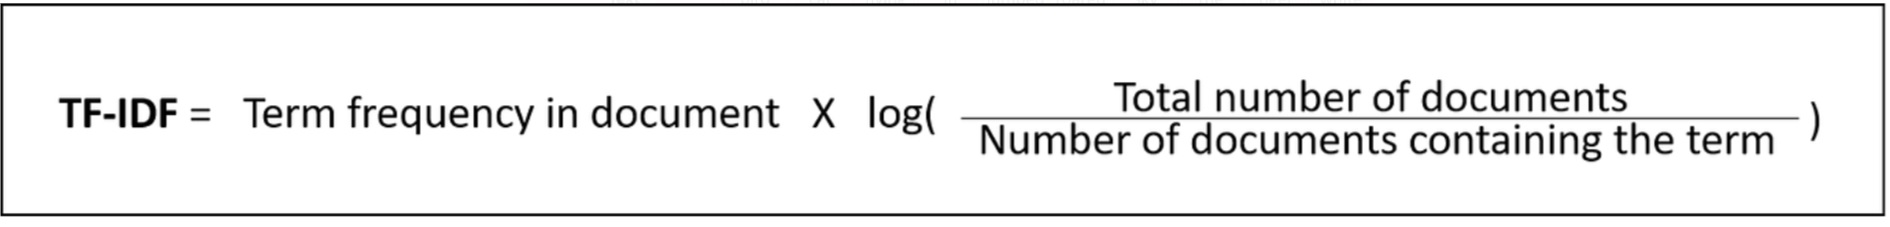


Starting with, import `TfidfVectorizer` from `sklearn.feature_extraction.text` responsible for converting a collection of raw text documents into a matrix of TF-IDF (Term Frequency-Inverse Document Frequency) features. This transformation is crucial for many machine learning tasks that require numerical input, as it effectively quantifies the importance of words within a document relative to a larger corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

Given a list of three example sentences stored in documents, a TfidfVectorizer from scikit-learn is created to convert the text into numerical vectors using the TF-IDF technique. The vectorizer fits the data and transforms the documents by building the vocabulary and calculating the IDF values, resulting in the TF-IDF matrix stored in X_tfidf. Finally, the vocabulary (feature names) and the TF-IDF matrix (converted to a dense NumPy array) are displayed for interpretation.



*   `tfidf_vectorizer = TfidfVectorizer()`: To create object from scikit-learn, which converts text data into a numerical vectors using the Term Frequency-Inverse Document (TF-IDF) method.
*  `X_tfidf = tfidf_vectorizer.fit_transform(documents)`: Fitted the vectorizer on the list of documents, it gets the vocabulary (rarest word in the documents) and calculates the IDF (Inverse-Document Frequency).
*  `tfidf_vectorizer.get_feature_names_out()`: Get all the features name (rarest word) in the list of documents.
*  `X_tfidf.toarray(): To convert the sparse matrix to a NumPy array format.



The input of this scenario is a list of three example of initialized `documents` variable containing three example of sentences such as "**This is the first document**", "**This document is the second document.**" and "**And this is the the third one**.". Created a `TfidfVectorizer` object named `tfidf_vectorizer` from scikit-learn, which converts text data into numerical vectors using the Term Frequency-Inverse Document Frequency (TF-IDF) method. The vectorizer is then fitted on the list of documents, where it builds the vocabulary (unique words across all documents) and calculates the IDF (Inverse Document Frequency) values in `X_tfidf = tfidf_vectorizer.fit_transform(documents)`. Finally, the output is displayed by printing the feature names using `tfidf_vectorizer.get_feature_names_out()` and the TF-IDF matrix by converting the sparse matrix to a dense NumPy array with `X_tfidf.toarray()`.


**Example Output**:

Final Text Representation:
Feature Names: ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
TF-IDF Matrix:
 [[0.         0.46941728 0.61722732 0.3645444  0.         0.
  0.3645444  0.         0.3645444 ]
 [0.         0.7284449  0.         0.28285122 0.         0.47890875
  0.28285122 0.         0.28285122]
 [0.49711994 0.         0.         0.29360705 0.49711994 0.
  0.29360705 0.49711994 0.29360705]]


**Comments and Observations**:

To better understand the significance of this TF-IDF vectorization process, it is important to understand the role TF-IDF plays in transforming textual data into meaningful numerical representations. These insights help explain why it's essential to use this technique, where it’s typically applied, and what limitations one should be aware of when interpreting the results.

*  Why we apply TF-IDF? because it's a statistical measure in natural language processing. It measures how often a word appears in a document. It balances term importance by combining local frequency within a document (TF) with rarity across the entire corpus (IDF), reducing the weight of overly common words while highlighting unique and relevant ones.
* `TfidfVectorizer()`: Convert a collection of raw documents to a matrix of TF-IDF features. It combines the functionalities of CountVectorizer and TfidfTransformer in one step.

*  Limitations: However, it disregards word order and deeper semantic relationships, which can limit its ability to capture meaning in more complex language tasks.





In [ ]:
documents = ["This is the first document.",
              "This document is the second document.",
              "And this is the third one."]

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)


tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)

# Convert to a DataFrame for readability
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    index=[f"Document {i+1}" for i in range(len(documents))],
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("Final TF-IDF Table:\n")
print(df_tfidf.round(3))


Final TF-IDF Table:

              and  document  first     is    one  second    the  third   this
Document 1  0.000     0.469  0.617  0.365  0.000   0.000  0.365  0.000  0.365
Document 2  0.000     0.728  0.000  0.283  0.000   0.479  0.283  0.000  0.283
Document 3  0.497     0.000  0.000  0.294  0.497   0.000  0.294  0.497  0.294
